# Transformers

`Transformer` stacks the attention from `attention.ipynb` into the usual residual block and
adds the pieces a real model needs: position information, conditioning, and regularization.

This notebook walks the module's options and then trains it on two small tasks that fit
comfortably on a CPU — one encoder (sorting) and one decoder (autoregressive sampling).

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from probjax.nn import (
    LearnablePosEncode,
    PosEncode,
    RotaryPosEncode,
    Transformer,
)
from probjax.nn.layers.attention import InducedSelfAttention
from probjax.nn.pallas_kernels import CausalMask

jax.config.update("jax_platform_name", "cpu")

## 1. The block

One layer is two residual sub-blocks, both pre-norm:

```
q = q + attention(norm(q))          # mix across positions
q = q + mlp(norm(q))                # mix across features
```

Pre-norm (normalizing the *input* of each sub-block rather than the output) is what keeps
deep stacks trainable without a learning-rate warmup babysitting act.

The four positional arguments are the whole geometry: `model_dim` is the residual stream
width, `num_heads` × `attn_size` is the attention capacity, `num_layers` is the depth.
`widening_factor` sets how much wider the MLP is than the stream — 4 is the convention,
and it is where most of the parameters live.

In [2]:
model = Transformer(model_dim=64, num_heads=4, num_layers=2, attn_size=16, rngs=nnx.Rngs(0))

x = jax.random.normal(jax.random.key(0), (2, 12, 64))
print("in", x.shape, "-> out", model(x).shape, "(shape preserving)")

for factor in (1, 2, 4):
    tf = Transformer(64, 4, 2, 16, widening_factor=factor, rngs=nnx.Rngs(0))
    total = sum(p.size for _, p in nnx.to_flat_state(nnx.state(tf, nnx.Param)))
    print(f"widening_factor={factor}: {total:>7,} params")

in (2, 12, 64) -> out (2, 12, 64) (shape preserving)
widening_factor=1:  50,432 params


widening_factor=2:  66,944 params
widening_factor=4:  99,968 params


## 2. Position encodings

Attention is a weighted sum over positions, and a sum does not care about order. A
transformer with no position information is therefore a **set** function: permute the
input, and the output is permuted the same way and otherwise unchanged.

That is easy to state and easy to disbelieve, so here it is measured:

In [3]:
perm = jax.random.permutation(jax.random.key(1), 12)
out = model(x)
out_perm = model(x[:, perm])
print("permuting the input just permutes the output:",
      bool(jnp.allclose(out[:, perm], out_perm, atol=1e-5)))

permuting the input just permutes the output: True


So order has to be injected. Three ways, all shaped `(batch, seq, dim) -> (batch, seq, dim)`
and applied to the embeddings before the stack:

| | how | notes |
|---|---|---|
| `PosEncode` | fixed sinusoids added | no parameters, extrapolates to unseen lengths |
| `LearnablePosEncode` | a learned vector per position | more flexible, hard-capped at `max_seq_len` |
| `RotaryPosEncode` | rotates feature pairs by angle ∝ position | encodes *relative* offsets; the current default in most LLMs |

A fourth option is to skip position encodings entirely and use a distance-aware attention
bias instead (`SymmetricAlibiBias`, `DistanceDecayBias` from `attention.ipynb`).

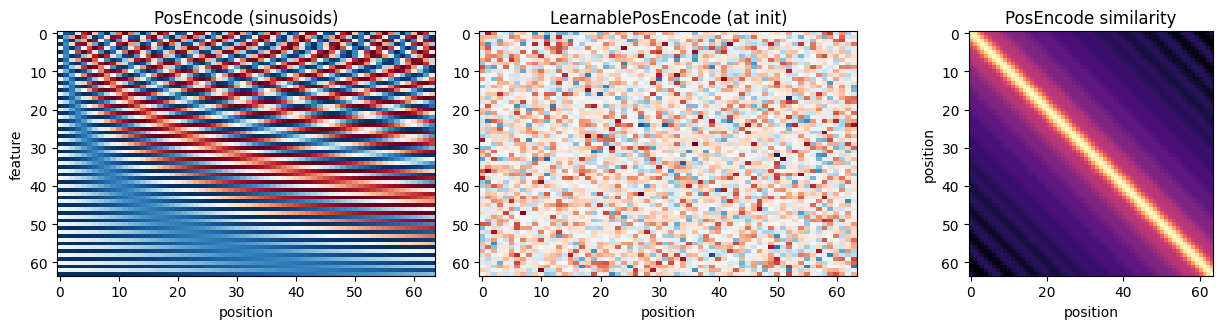

In [4]:
seq_len, dim = 64, 64
zeros = jnp.zeros((1, seq_len, dim))

sinusoidal = PosEncode(max_seq_len=seq_len, rngs=nnx.Rngs(0))(zeros)[0]
learned = LearnablePosEncode(dim, max_seq_len=seq_len, rngs=nnx.Rngs(0))(zeros)[0]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].imshow(sinusoidal.T, aspect="auto", cmap="RdBu")
axes[0].set(title="PosEncode (sinusoids)", xlabel="position", ylabel="feature")
axes[1].imshow(learned.T, aspect="auto", cmap="RdBu")
axes[1].set(title="LearnablePosEncode (at init)", xlabel="position")
# Sinusoids make the dot product between two positions a function of their distance.
axes[2].imshow(sinusoidal @ sinusoidal.T, cmap="magma")
axes[2].set(title="PosEncode similarity", xlabel="position", ylabel="position")
fig.tight_layout()

## 3. Task A — sorting (encoder)

Sort a sequence of digits. Every output position needs to look at every input position, so
this is a pure encoder job: full attention, no mask. The model sees the sequence and emits
the sorted sequence in one shot — nothing autoregressive about it.

In [5]:
VOCAB, SEQ_LEN = 10, 16


class Sorter(nnx.Module):
    def __init__(self, dim, rngs):
        self.embed = nnx.Embed(VOCAB, dim, rngs=rngs)
        self.pos = PosEncode(max_seq_len=SEQ_LEN, rngs=rngs)
        self.body = Transformer(dim, num_heads=4, num_layers=2, attn_size=16, rngs=rngs)
        self.head = nnx.Linear(dim, VOCAB, rngs=rngs)

    def __call__(self, tokens):
        return self.head(self.body(self.pos(self.embed(tokens))))


def sorting_batch(key, batch_size):
    x = jax.random.randint(key, (batch_size, SEQ_LEN), 0, VOCAB)
    return x, jnp.sort(x, axis=-1)


sorter = Sorter(64, nnx.Rngs(0))
optimizer = nnx.Optimizer(sorter, optax.adamw(3e-3), wrt=nnx.Param)


@nnx.jit
def sorting_step(model, optimizer, x, y):
    def loss_fn(m):
        return optax.softmax_cross_entropy_with_integer_labels(m(x), y).mean()

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss

token accuracy    0.999
sequence accuracy 0.984


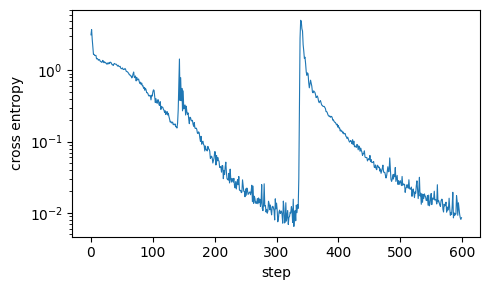

In [6]:
key = jax.random.key(0)
losses = []
for step in range(600):
    key, subkey = jax.random.split(key)
    losses.append(float(sorting_step(sorter, optimizer, *sorting_batch(subkey, 128))))

x_test, y_test = sorting_batch(jax.random.key(999), 512)
predicted = sorter(x_test).argmax(-1)
print(f"token accuracy    {float((predicted == y_test).mean()):.3f}")
print(f"sequence accuracy {float((predicted == y_test).all(-1).mean()):.3f}")

plt.figure(figsize=(5, 3))
plt.plot(losses, lw=0.8)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.tight_layout()

In [7]:
print("input     ", x_test[0])
print("prediction", predicted[0])
print("target    ", y_test[0])

input      [2 7 2 2 3 4 9 0 6 3 7 6 4 1 8 9]
prediction [0 1 2 2 2 3 3 4 4 6 6 7 7 8 9 9]
target     [0 1 2 2 2 3 3 4 4 6 6 7 7 8 9 9]


## 4. Task B — autoregressive decoding (decoder)

Same module, two changes: pass `mask=CausalMask()` so position *t* only sees positions
`≤ t`, and shift the input by one so predicting token *t* never gets to look at it.

The data is a sticky Markov chain — each bit repeats the previous one with probability 0.9.
That makes the task *checkable*: the chain's entropy rate is known in closed form, so we
can tell whether the model actually learned the distribution or merely a plausible-looking
approximation of it.

In [8]:
SEQ, P_STAY, BOS = 24, 0.9, 2


def sample_chain(key, batch_size):
    k_first, k_flip = jax.random.split(key)
    first = jax.random.bernoulli(k_first, 0.5, (batch_size, 1)).astype(jnp.int32)
    flips = (jax.random.uniform(k_flip, (batch_size, SEQ - 1)) > P_STAY).astype(jnp.int32)
    return jnp.concatenate([first, flips], axis=1).cumsum(axis=1) % 2


def shift_right(x):
    # Prepend a begin-of-sequence token so position t predicts x[t] from x[<t].
    bos = jnp.full((x.shape[0], 1), BOS, jnp.int32)
    return jnp.concatenate([bos, x[:, :-1]], axis=1)


class Decoder(nnx.Module):
    def __init__(self, dim, rngs):
        self.embed = nnx.Embed(3, dim, rngs=rngs)  # {0, 1, BOS}
        self.pos = LearnablePosEncode(dim, max_seq_len=SEQ, rngs=rngs)
        self.body = Transformer(dim, num_heads=4, num_layers=2, attn_size=16, rngs=rngs)
        self.head = nnx.Linear(dim, 2, rngs=rngs)

    def __call__(self, tokens):
        hidden = self.pos(self.embed(tokens))
        return self.head(self.body(hidden, mask=CausalMask()))


decoder = Decoder(64, nnx.Rngs(0))
dec_optimizer = nnx.Optimizer(decoder, optax.adamw(3e-3), wrt=nnx.Param)


@nnx.jit
def decoder_step(model, optimizer, x):
    def loss_fn(m):
        return optax.softmax_cross_entropy_with_integer_labels(m(shift_right(x)), x).mean()

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss

In [9]:
key = jax.random.key(0)
for step in range(400):
    key, subkey = jax.random.split(key)
    loss = decoder_step(decoder, dec_optimizer, sample_chain(subkey, 256))

# Entropy rate of the chain: one fair coin for the first bit, then a Bernoulli(0.9) flip.
bit_entropy = -(P_STAY * jnp.log(P_STAY) + (1 - P_STAY) * jnp.log(1 - P_STAY))
floor = float((bit_entropy * (SEQ - 1) + jnp.log(2.0)) / SEQ)
print(f"final loss    {float(loss):.4f} nats/token")
print(f"entropy floor {floor:.4f} nats/token  <- the best any model can do")

final loss    0.3412 nats/token
entropy floor 0.3404 nats/token  <- the best any model can do


The loss sits on the entropy floor, so the model has learned the chain and not just
memorized something that scores well. The stronger test is to *sample* from it and check
that the samples have the right statistics.

Sampling is a loop: run the model, take the logits at the current position, sample a token,
write it back, repeat. This is the naive $O(T)$-forward-passes version — no KV cache — which
is fine at `SEQ=24` and keeps the loop readable. `vmap` over the keys draws 2000 sequences
at once.

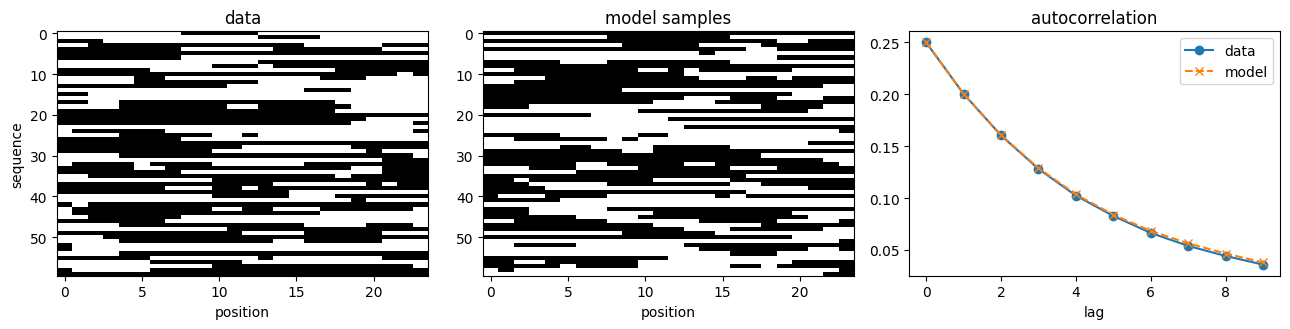

In [10]:
@nnx.jit
def sample_ar(model, keys):
    def one_sequence(key):
        def body(t, carry):
            tokens, out, key = carry
            logits = model(tokens[None])[0, t]
            key, subkey = jax.random.split(key)
            token = jax.random.categorical(subkey, logits).astype(jnp.int32)
            # Write the sample to the output, and feed it in at the next position.
            return jnp.where(jnp.arange(SEQ) == t + 1, token, tokens), out.at[t].set(token), key

        prompt = jnp.full((SEQ,), BOS, jnp.int32)
        _, out, _ = jax.lax.fori_loop(0, SEQ, body, (prompt, jnp.zeros((SEQ,), jnp.int32), key))
        return out

    return jax.vmap(one_sequence)(keys)


samples = sample_ar(decoder, jax.random.split(jax.random.key(7), 2000))
data = sample_chain(jax.random.key(11), 2000)


def autocorrelation(x, max_lag=10):
    centered = x.astype(jnp.float32) - 0.5
    return jnp.array([(centered[:, : SEQ - l] * centered[:, l:]).mean() for l in range(max_lag)])


fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].imshow(data[:60], cmap="Greys_r", aspect="auto", interpolation="nearest")
axes[0].set(title="data", xlabel="position", ylabel="sequence")
axes[1].imshow(samples[:60], cmap="Greys_r", aspect="auto", interpolation="nearest")
axes[1].set(title="model samples", xlabel="position")
axes[2].plot(autocorrelation(data), "o-", label="data")
axes[2].plot(autocorrelation(samples), "x--", label="model")
axes[2].set(title="autocorrelation", xlabel="lag")
axes[2].legend()
fig.tight_layout()

## 5. Conditioning

Two different ways to feed something else into the stack, and they are not interchangeable:

- **`context_dim`** — a single vector per example (a class label, a diffusion timestep, a
  set of simulator parameters). It is fused into *every* block by `context_fusion_cls`,
  which defaults to `AffineFuse`: the context predicts a per-feature scale and shift, i.e.
  FiLM conditioning. This is the path every generative model in `examples/nn/generative/`
  uses for the noise level.
- **`enable_cross_attention`** — a whole second *sequence*, attended over. Each layer gets
  an extra cross-attention sub-block between the self-attention and the MLP. Use this when
  the conditioning has structure and length of its own (an encoded source sentence, an
  image's patch tokens).

In [11]:
conditioned = Transformer(64, 4, 2, 16, context_dim=5, rngs=nnx.Rngs(0))
context = jax.random.normal(jax.random.key(1), (2, 5))
print("context conditioning:", conditioned(x, context=context).shape)

cross = Transformer(64, 4, 2, 16, enable_cross_attention=True, kv_in_features=16, rngs=nnx.Rngs(0))
memory = jax.random.normal(jax.random.key(2), (2, 20, 16))
print("cross-attention:     ", cross(x, memory, memory).shape)

other = jax.random.normal(jax.random.key(9), (2, 5))
print("context changes the output at init:",
      not bool(jnp.allclose(conditioned(x, context=context), conditioned(x, context=other))))

context conditioning: (2, 12, 64)


cross-attention:      (2, 12, 64)
context changes the output at init: False


**That `False` is not a bug** — it is the single most confusing thing about this module,
so it is worth showing rather than burying.

`AffineFuse` builds its scale/shift with a zero-initialized output projection, so at step 0
the predicted scale is 1 and the shift is 0 and the conditioning is *exactly the identity*.
The network therefore starts out as the unconditioned model and grows its dependence on the
context during training. That is deliberate (the adaLN-Zero trick) and it is why deep
conditioned diffusion models train stably instead of thrashing early on.

The practical consequence: **you cannot smoke-test your conditioning wiring at
initialization.** A correctly wired context and a context that is silently dropped on the
floor look identical until weights move. Perturb the conditioner to see the wiring is
live:

In [12]:
params = nnx.state(conditioned, nnx.Param)
perturbed = 0
for path, param in nnx.to_flat_state(params):
    names = [str(p) for p in path]
    if names[0].startswith("context_layers") and names[-2:] == ["proj", "kernel"]:
        param[...] = param[...] + 0.05 * jax.random.normal(jax.random.key(perturbed), param.shape)
        perturbed += 1
nnx.update(conditioned, params)

print(f"perturbed {perturbed} zero-initialized conditioner projections")
print("context changes the output now:",
      not bool(jnp.allclose(conditioned(x, context=context), conditioned(x, context=other))))

perturbed 4 zero-initialized conditioner projections
context changes the output now: True


### Regularization

`dropout_rate`, `dropout_rate_attn` and `drop_path_rate` (stochastic depth — drop an entire
residual branch) all need `deterministic=False` and an `rng` to be active. Forgetting the
rng is the classic silent bug: the model trains as if regularization were off.

In [13]:
regularized = Transformer(64, 4, 2, 16, dropout_rate=0.1, drop_path_rate=0.1, rngs=nnx.Rngs(0))
train_out = regularized(x, deterministic=False, rng=jax.random.key(3))
eval_out = regularized(x, deterministic=True)
print("train != eval:", not bool(jnp.allclose(train_out, eval_out)))

train != eval: True


## 6. Sets: `InducedSelfAttention`

Self-attention over `n` tokens costs $O(n^2)$. When the input is an unordered *set* that is
much longer than it is complex, `InducedSelfAttention` routes it through `m` learned
inducing points instead — set attends to inducing points, inducing points attend back —
which drops the cost to $O(nm)$. It is permutation-equivariant by construction, so it is
the natural encoder for point clouds and simulation-based-inference observations.

In [14]:
induced = InducedSelfAttention(num_heads=4, in_features=16, num_inducing_points=8, rngs=nnx.Rngs(0))
points = jax.random.normal(jax.random.key(3), (2, 500, 16))
print("500 set elements through 8 inducing points:", induced(points).shape)

500 set elements through 8 inducing points: (2, 500, 16)


## Where to go next

- `attention.ipynb` — masks, biases and the fused `flex_attention` kernel.
- `architectures.ipynb` — the rest of `probjax.nn.nets`.
- `sharding.ipynb` — splitting this model across devices.
- `examples/nn/generative/` — `Transformer` as a denoiser (`simformer.ipynb`) and as an
  autoregressive image model (`autoregressive.ipynb`).